In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

# TODO:
- EDA
- Baseline
- Test more models (justify choices)

# Exploratory Data Analysis

Let us load the data and check its shape.

In [10]:
train_data = pd.read_csv("data/predictive_maintenance_train.csv")
test_data = pd.read_csv("data/predictive_maintenance_test.csv")

print(train_data.shape)
print(test_data.shape)


(1300, 13)
(350, 13)


The shape of the data corresponds to the expected number of samples and variables in both train and test dataset.

### Target Analysis

Let's begin the EDA by examining the target variable, i.e., whether a machine will encounter a failure within the next 30 days (failure_30d). Since it is a boolean variable, our task naturally lends towards classification.

failure_30d
0    0.866154
1    0.133846
Name: proportion, dtype: float64


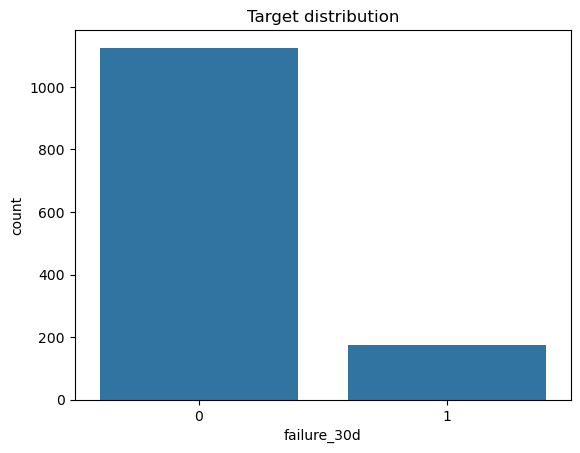

In [11]:
print(train_data["failure_30d"].value_counts(normalize=True))

sns.countplot(data=train_data, x="failure_30d")
plt.title("Target distribution")
plt.show()

From the low frequency of the targeted event in train data, shown by the plot above, we can infer that the event is not likely to happen.

TOADD: EXPLANATIONS FOR EACH PLOT GROUP BELOW

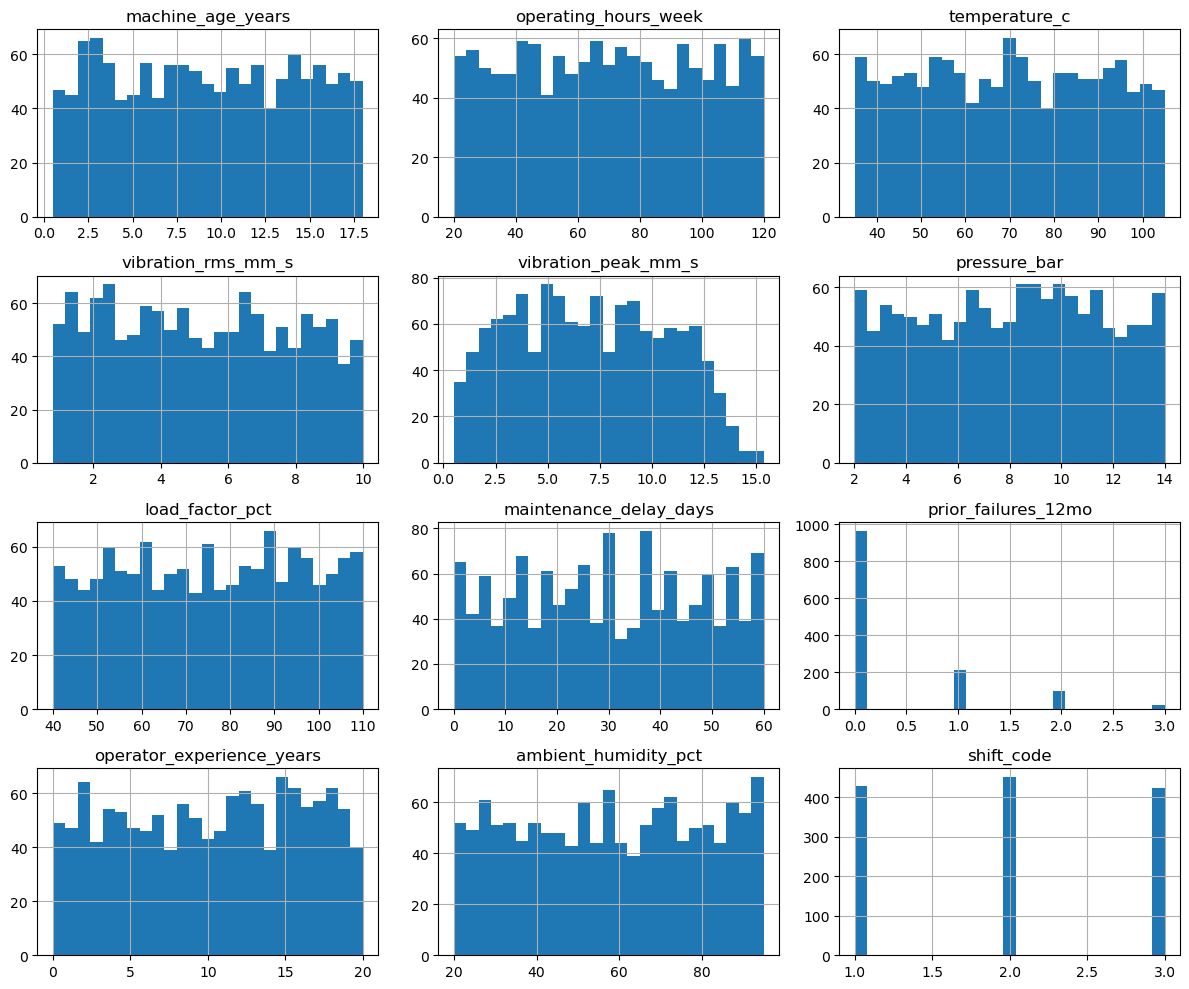

In [12]:
# Feature distributions
train_data.drop(columns=["failure_30d"]).hist(bins=25, figsize=(12, 10))
plt.tight_layout()
plt.show()

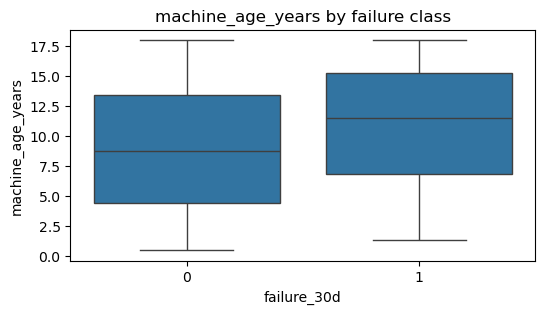

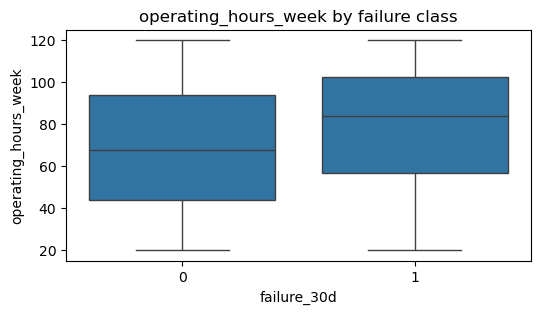

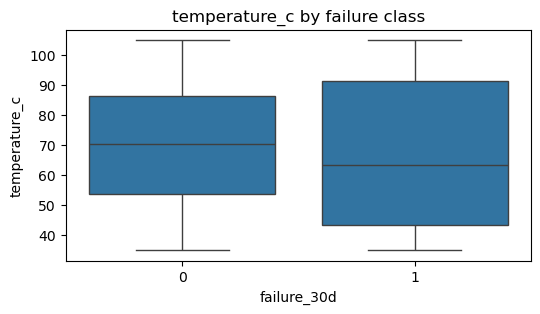

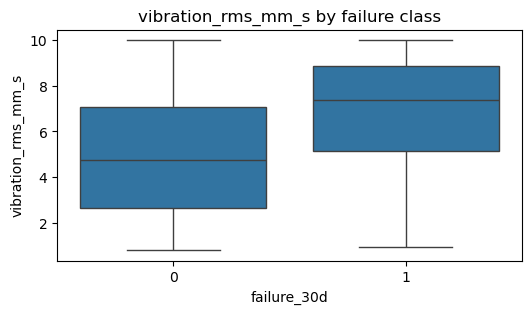

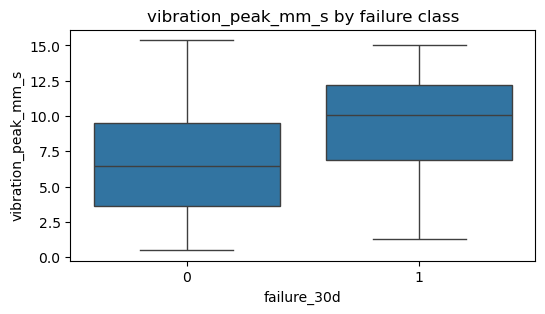

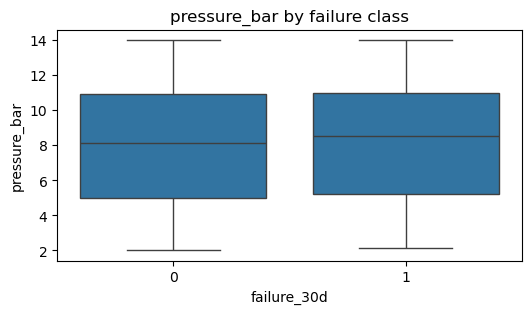

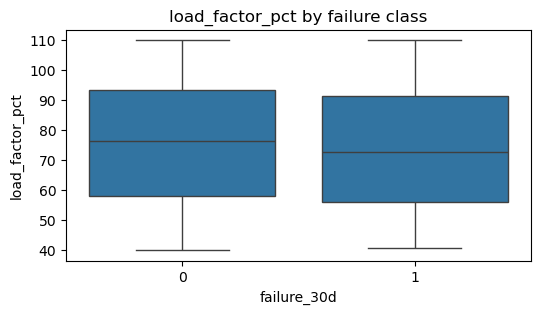

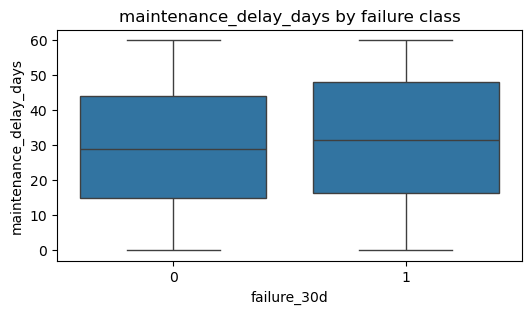

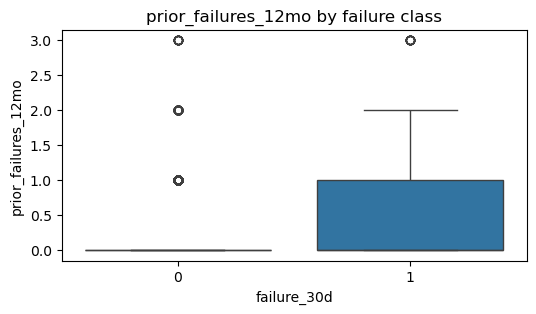

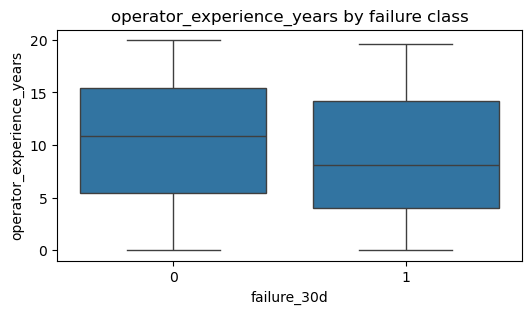

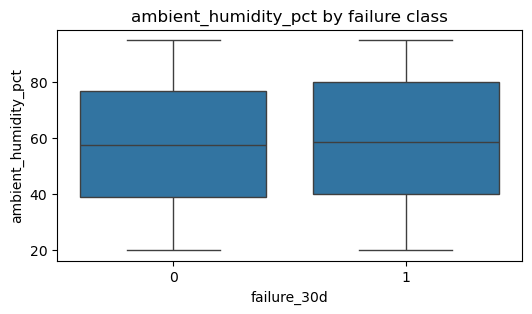

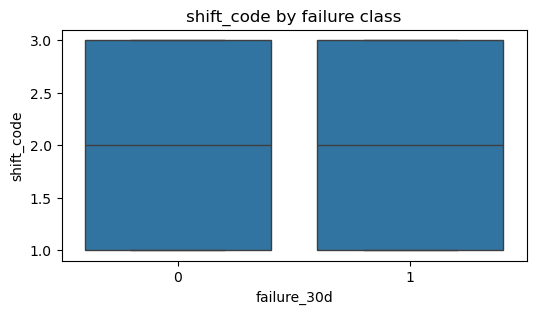

In [13]:
# Boxplots by target
for col in [c for c in train_data.columns if c != "failure_30d"]:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=train_data, x="failure_30d", y=col)
    plt.title(f"{col} by failure class")
    plt.show()

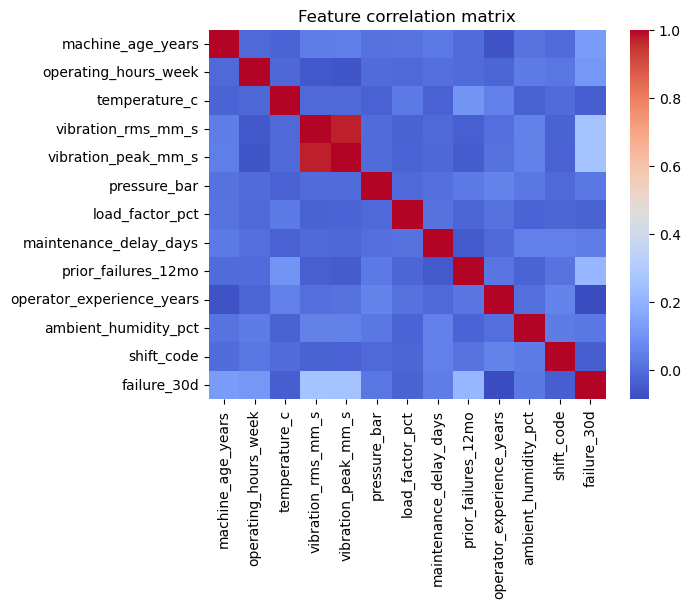

In [20]:
# Correlation heatmap
corr = train_data.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature correlation matrix")
plt.show()

EDA TODO:
- write explanations and reasoning behind each plot
- think about removing one of the vibration variables
- check for other correlations
- failure rates by shift?
- look for failure patterns
- look at step 8 of prompt 

### Features Analysis